In [18]:
import joblib
import numpy as np

# Load saved EEG-BIS dataset
data = joblib.load('A_data_10_sec_50.pkl')

x = data['x']  # Shape: (N, 1280)
y = data['y']  # Shape: (N,)
c = data['c']  # Shape: (N,), case IDs



print("Original shape:", x.shape)


valid_mask = ~np.isnan(x).any(axis=1)


x_clean = x[valid_mask]
y_clean = y[valid_mask]
c_clean = c[valid_mask]

print("Cleaned shape:", x_clean.shape)
print("NaNs remaining:", np.isnan(x_clean).sum())


x = x_clean
y = y_clean
c = c_clean



# Print basic info
print(f"EEG segments shape: {x.shape}")
print(f"BIS labels shape: {y.shape}")
print(f"Case ID shape: {c.shape}")


Original shape: (206301, 1280)
Cleaned shape: (205945, 1280)
NaNs remaining: 0
EEG segments shape: (205945, 1280)
BIS labels shape: (205945,)
Case ID shape: (205945,)


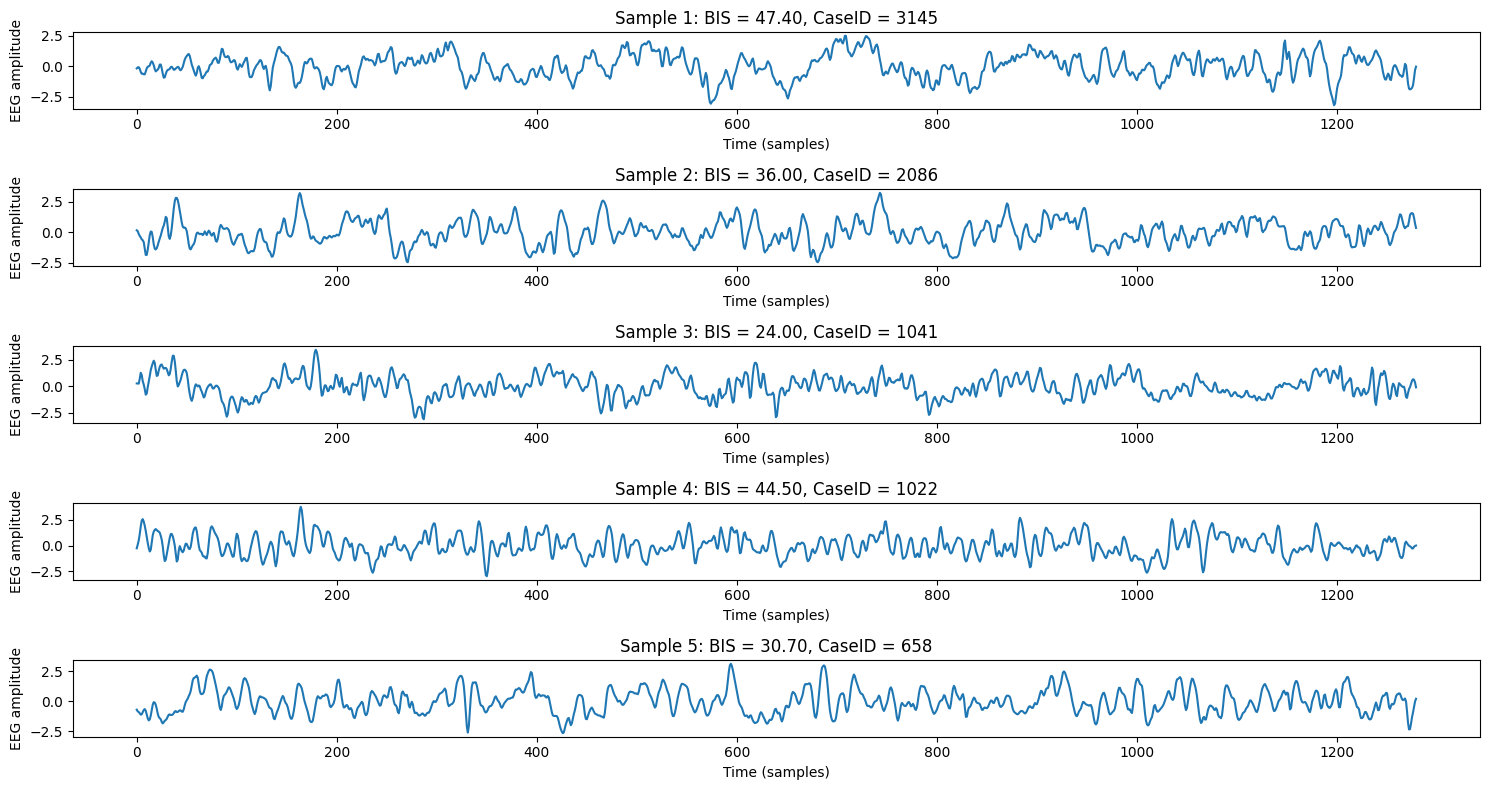

In [19]:
import matplotlib.pyplot as plt

# Plot a few random EEG segments with BIS values
num_samples = 5
indices = np.random.choice(len(x), size=num_samples, replace=False)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(indices):
    plt.subplot(num_samples, 1, i + 1)
    plt.plot(x[idx])
    plt.title(f"Sample {i+1}: BIS = {y[idx]:.2f}, CaseID = {c[idx]}")
    plt.xlabel('Time (samples)')
    plt.ylabel('EEG amplitude')
    plt.tight_layout()
plt.show()


# Group Samples by Subject (CaseID)

In [20]:
import numpy as np
import pandas as pd
from collections import defaultdict

# Create a dataframe to work easily
df = pd.DataFrame({
    'caseid': c,
    'bis': y
})

# Group sample indices by caseid
caseid_to_indices = defaultdict(list)
for idx, cid in enumerate(c):
    caseid_to_indices[cid].append(idx)

print(f"Total unique subjects (caseids): {len(caseid_to_indices)}")


Total unique subjects (caseids): 50


# Compute BIS Stats Per Subject

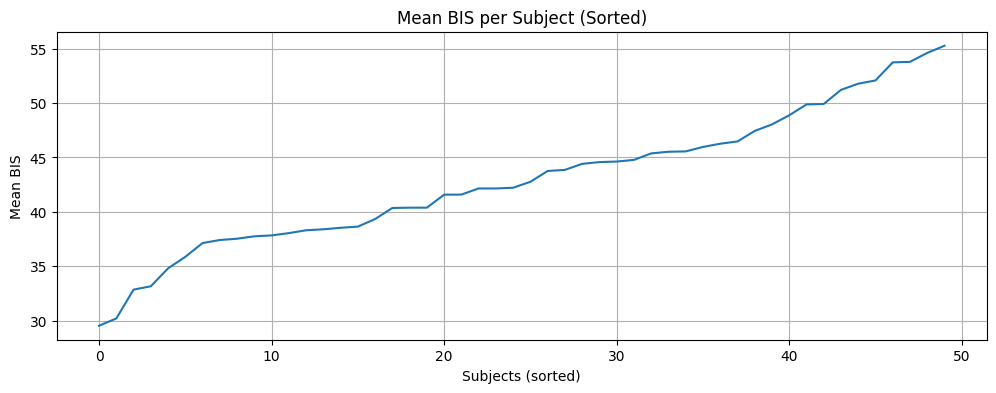

In [21]:
# Compute BIS stats for each subject
case_stats = []
for cid, indices in caseid_to_indices.items():
    bis_vals = y[indices]
    case_stats.append({
        'caseid': cid,
        'min_bis': np.min(bis_vals),
        'max_bis': np.max(bis_vals),
        'mean_bis': np.mean(bis_vals),
        'count': len(bis_vals)
    })

df_stats = pd.DataFrame(case_stats)
df_stats.sort_values(by='mean_bis', inplace=True)

# Optional: visualize BIS distribution across subjects
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df_stats['mean_bis'].values)
plt.title("Mean BIS per Subject (Sorted)")
plt.xlabel("Subjects (sorted)")
plt.ylabel("Mean BIS")
plt.grid(True)
plt.show()


# Select Test Subjects with Diverse BIS Coverage

In [22]:
print("Subjects with mean BIS < 40:", (df_stats['mean_bis'] < 40).sum())
print("Subjects with mean BIS 40–60:", ((df_stats['mean_bis'] >= 40) & (df_stats['mean_bis'] <= 60)).sum())
print("Subjects with mean BIS > 60:", (df_stats['mean_bis'] > 60).sum())


Subjects with mean BIS < 40: 17
Subjects with mean BIS 40–60: 33
Subjects with mean BIS > 60: 0


In [23]:
# Split subject pools
low_pool  = df_stats[df_stats['mean_bis'] < 40]
mid_pool  = df_stats[(df_stats['mean_bis'] >= 40) & (df_stats['mean_bis'] <= 60)]
high_pool = df_stats[df_stats['mean_bis'] > 60]

# How many to select
#low_n, mid_n, high_n = 10, 10, min(1, len(high_pool))  # only 1 high-BIS subject


low_n, mid_n, high_n = 10, 10, 0  # only 1 high-BIS subject


# Sample
low_bis  = low_pool.sample(low_n, random_state=42)
mid_bis  = mid_pool.sample(mid_n, random_state=42)
high_bis = high_pool.sample(high_n, random_state=42)

# Combine into test set
test_caseids = set(pd.concat([low_bis, mid_bis, high_bis])['caseid'])
train_caseids = set(caseid_to_indices.keys()) - test_caseids

print(f"Selected {len(test_caseids)} test subjects")
print(f"Remaining {len(train_caseids)} training subjects")


Selected 20 test subjects
Remaining 30 training subjects


In [24]:
# Get sample indices
train_indices = [idx for cid in train_caseids for idx in caseid_to_indices[cid]]
test_indices  = [idx for cid in test_caseids  for idx in caseid_to_indices[cid]]

# Split the data
x_train, y_train = x[train_indices], y[train_indices]
x_test, y_test   = x[test_indices], y[test_indices]

print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")


x_train shape: (109817, 1280), y_train shape: (109817,)
x_test shape: (96128, 1280), y_test shape: (96128,)


In [25]:
import gc


del df_stats
del caseid_to_indices
del c
del low_bis, mid_bis, high_bis
del low_pool, mid_pool, high_pool
del x
del y

del x_clean
del y_clean
del c_clean
del case_stats

gc.collect()


19022

In [26]:
import sys

def get_variable_sizes(scope_vars):
    sizes = []
    for name, val in scope_vars.items():
        try:
            size = sys.getsizeof(val)
            sizes.append((name, size))
        except TypeError:
            pass
    sizes.sort(key=lambda x: x[1], reverse=True)
    for name, size in sizes:
        print(f"{name:<30} {size / 1024 ** 2:>10.2f} MB")

get_variable_sizes(locals())


x_train                           1072.43 MB
x_test                             938.75 MB
df                                   3.14 MB
train_indices                        0.86 MB
y_train                              0.84 MB
test_indices                         0.76 MB
y_test                               0.73 MB
valid_mask                           0.20 MB
indices                              0.06 MB
bis_vals                             0.06 MB
_i14                                 0.02 MB
_i17                                 0.01 MB
best_model_wts                       0.01 MB
test_caseids                         0.00 MB
train_caseids                        0.00 MB
tqdm                                 0.00 MB
DataLoader                           0.00 MB
SEBlock1D                            0.00 MB
ConvSEBlock1D                        0.00 MB
TemporalConvMemory                   0.00 MB
LightUNet_SE_ConvLSTM                0.00 MB
CosineAnnealingWarmRestarts          0.00 MB
Dataset   

In [27]:
import torch
from torch.utils.data import Dataset

class EEGBISDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)  # shape: (N, 1280)
        self.y = torch.tensor(y, dtype=torch.float32)  # shape: (N,)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        # Add channel dimension for CNNs: (1280,) -> (1, 1280)
        eeg = self.x[idx].unsqueeze(0)  # (1, 1280)
        bis = self.y[idx]               # scalar
        return eeg, bis



In [28]:
train_dataset = EEGBISDataset(x_train, y_train)
test_dataset  = EEGBISDataset(x_test, y_test)


In [29]:
del x_train
del y_train
del x_test
del y_test
gc.collect()

0

In [30]:
from torch.utils.data import DataLoader

batch_size = 64

#train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
#test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)



train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)


In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNet1D_BiLSTM(nn.Module):
    def __init__(self, input_channels=1, lstm_hidden_size=64):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock1D(input_channels, 32)
        self.pool1 = nn.MaxPool1d(2)

        self.enc2 = ConvBlock1D(32, 64)
        self.pool2 = nn.MaxPool1d(2)

        self.enc3 = ConvBlock1D(64, 128)
        self.pool3 = nn.MaxPool1d(2)

        self.enc4 = ConvBlock1D(128, 256)
        self.pool4 = nn.MaxPool1d(2)

        # Bottleneck BiLSTM
        self.bilstm = nn.LSTM(input_size=256, hidden_size=lstm_hidden_size, num_layers=1,
                              bidirectional=True, batch_first=True)

        # Decoder
        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec1 = ConvBlock1D(2 * lstm_hidden_size + 256, 128)

        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec2 = ConvBlock1D(128 + 128, 64)

        self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec3 = ConvBlock1D(64 + 64, 32)

        self.up4 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec4 = ConvBlock1D(32 + 32, 16)

        # Final regression layer
        self.final = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),   # Output shape: (B, 16, 1)
            nn.Flatten(),              # → (B, 16)
            nn.Linear(16, 1)           # → (B, 1)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        pooled = self.pool4(e4)

        # BiLSTM expects (B, T, C) → input is (B, 256, time)
        lstm_in = pooled.permute(0, 2, 1)  # (B, T, C)
        lstm_out, _ = self.bilstm(lstm_in) # (B, T, 2*H)
        lstm_out = lstm_out.permute(0, 2, 1)  # (B, 2*H, T)

        # Decoder
        e4_resized = F.interpolate(e4, size=lstm_out.shape[-1])
        d1 = self.up1(torch.cat([lstm_out, e4_resized], dim=1))
        d1 = self.dec1(d1)
        
        e3_resized = F.interpolate(e3, size=d1.shape[-1])
        d2 = self.up2(torch.cat([d1, e3_resized], dim=1))
        d2 = self.dec2(d2)
        
        e2_resized = F.interpolate(e2, size=d2.shape[-1])
        d3 = self.up3(torch.cat([d2, e2_resized], dim=1))
        d3 = self.dec3(d3)
        
        e1_resized = F.interpolate(e1, size=d3.shape[-1])
        d4 = self.up4(torch.cat([d3, e1_resized], dim=1))
        d4 = self.dec4(d4)

        out = self.final(d4)
        return out.squeeze(1)  # (B,)
#_______________________________________________________________________________________________________________________________________________________________________________________________________________________________________

import torch
import torch.nn as nn
import torch.nn.functional as F

# Squeeze-and-Excitation block for 1D
class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, t = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

# Conv1D block with SE and Dropout
class ConvSEBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1, dropout_prob=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch, momentum=0.05),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch, momentum=0.05),
            nn.ReLU(inplace=True)
        )
        self.se = SEBlock1D(out_ch)
        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, x):
        x = self.conv(x)
        x = self.se(x)
        x = self.dropout(x)
        return x

# Lightweight ConvLSTM-style module
class TemporalConvMemory(nn.Module):
    def __init__(self, channels, kernel_size=5):
        super().__init__()
        self.depthwise = nn.Conv1d(
            channels, channels, kernel_size=kernel_size,
            padding=kernel_size // 2, groups=channels
        )
        self.pointwise = nn.Conv1d(channels, channels, kernel_size=1)

    def forward(self, x):
        mem = self.depthwise(x)
        mem = F.relu(mem)
        mem = self.pointwise(mem)
        return mem + x

# Final optimized model
class LightUNet_SE_ConvLSTM(nn.Module):
    def __init__(self, input_channels=1, dropout_prob=0.2):
        super().__init__()
        # Encoder
        self.enc1 = ConvSEBlock1D(input_channels, 32, dropout_prob=dropout_prob)
        self.down1 = nn.Conv1d(32, 32, kernel_size=3, stride=2, padding=1)

        self.enc2 = ConvSEBlock1D(32, 64, dropout_prob=dropout_prob)
        self.down2 = nn.Conv1d(64, 64, kernel_size=3, stride=2, padding=1)

        self.enc3 = ConvSEBlock1D(64, 128, dropout_prob=dropout_prob)
        self.down3 = nn.Conv1d(128, 128, kernel_size=3, stride=2, padding=1)

        # Temporal memory (ConvLSTM-lite)
        self.temporal = TemporalConvMemory(128)

        # Decoder (channel corrections made here!)
        self.up3 = nn.ConvTranspose1d(128, 64, kernel_size=2, stride=2)
        self.dec3 = ConvSEBlock1D(192, 64, dropout_prob=dropout_prob)  # 64 (up) + 128 (skip)

        self.up2 = nn.ConvTranspose1d(64, 32, kernel_size=2, stride=2)
        self.dec2 = ConvSEBlock1D(96, 32, dropout_prob=dropout_prob)   # 32 (up) + 64 (skip)

        self.up1 = nn.ConvTranspose1d(32, 16, kernel_size=2, stride=2)
        self.dec1 = ConvSEBlock1D(48, 16, dropout_prob=dropout_prob)   # 16 (up) + 32 (skip)

        # Output
        self.out = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)       # (B, 32, T)
        d1 = self.down1(e1)     # (B, 32, T/2)

        e2 = self.enc2(d1)      # (B, 64, T/2)
        d2 = self.down2(e2)     # (B, 64, T/4)

        e3 = self.enc3(d2)      # (B, 128, T/4)
        d3 = self.down3(e3)     # (B, 128, T/8)

        # Bottleneck
        bottleneck = self.temporal(d3)  # (B, 128, T/8)

        # Decoder
        u3 = self.up3(bottleneck)
        u3 = F.interpolate(u3, size=e3.shape[-1])
        d3 = self.dec3(torch.cat([u3, e3], dim=1))

        u2 = self.up2(d3)
        u2 = F.interpolate(u2, size=e2.shape[-1])
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        u1 = F.interpolate(u1, size=e1.shape[-1])
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        return self.out(d1).squeeze(1)  # (B,)




In [32]:

#model = LightUNet_SE_ConvLSTM(input_channels=1)
#from torchinfo import summary
#summary(model)

In [33]:
#model = UNet1D_BiLSTM(input_channels=1, lstm_hidden_size=64)
model = LightUNet_SE_ConvLSTM(input_channels=1)
'''print(model)

# Send to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)
model = model.to(device)
'''




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#model = UNet1D_BiLSTM(input_channels=1, lstm_hidden_size=64)
model = LightUNet_SE_ConvLSTM(input_channels=1, dropout_prob=0.2)

# If multiple GPUs are available, use DataParallel
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs with DataParallel...")
    model = nn.DataParallel(model)

# Send to device
model = model.to(device)

In [34]:
import datetime
import os
import time
import copy
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from tqdm import tqdm

# -------------------------
# (re)define train/val loops
# -------------------------
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    pbar = tqdm(dataloader, desc="Training", leave=False)

    for x_batch, y_batch in pbar:
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        preds = model(x_batch)
        # constrain outputs to [0, 100] without changing the model
        preds = torch.clamp(preds, 0.0, 100.0)

        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_batch.size(0)
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    return running_loss / len(dataloader.dataset)


def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    pbar = tqdm(dataloader, desc="Validating", leave=False)

    with torch.no_grad():
        for x_batch, y_batch in pbar:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            preds = model(x_batch)
            preds = torch.clamp(preds, 0.0, 100.0)

            loss = criterion(preds, y_batch)
            running_loss += loss.item() * x_batch.size(0)
            pbar.set_postfix({'val_loss': f"{loss.item():.4f}"})

    return running_loss / len(dataloader.dataset)


# -------------------------
# logging setup (unchanged)
# -------------------------
os.makedirs("logs", exist_ok=True)
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
log_file_path = f"logs/experiment_{timestamp}.txt"

with open(log_file_path, 'w') as f:
    f.write(f"Experiment Log - {timestamp}\n")
    f.write(f"{'-'*50}\n")

# -------------------------
# hyperparams & objects
# -------------------------
epochs = 100
patience = 5                          # early stopping patience
best_val_loss = float('inf')
patience_counter = 0

criterion = nn.SmoothL1Loss(beta=1.0)  # Huber

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# Cosine with warm restarts; step once per epoch
scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,          # epochs until first restart
    T_mult=2,        # period multiplier after each restart
    eta_min=1e-6
)

# save best weights
best_model_wts = copy.deepcopy(model.state_dict())

print("Training Model:", model)

for epoch in range(1, epochs + 1):
    start_time = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss   = validate(model, test_loader,  criterion, device)

    # step scheduler per epoch (no val_loss needed)
    scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - start_time

    log_line = (
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_time:.2f}s"
    )
    print(log_line)
    with open(log_file_path, 'a') as f:
        f.write(log_line + '\n')

    # early stopping on best val
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        model_save_path = "logs/model_best.pt"
        torch.save(best_model_wts, model_save_path)
        with open(log_file_path, 'a') as f:
            f.write(f"Saved best model at epoch {epoch} → {model_save_path}\n")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

# restore best model
model.load_state_dict(best_model_wts)
print("Best validation loss:", best_val_loss)


Training Model: LightUNet_SE_ConvLSTM(
  (enc1): ConvSEBlock1D(
    (conv): Sequential(
      (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.05, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (4): BatchNorm1d(32, eps=1e-05, momentum=0.05, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (se): SEBlock1D(
      (pool): AdaptiveAvgPool1d(output_size=1)
      (fc): Sequential(
        (0): Linear(in_features=32, out_features=4, bias=False)
        (1): ReLU(inplace=True)
        (2): Linear(in_features=4, out_features=32, bias=False)
        (3): Sigmoid()
      )
    )
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (down1): Conv1d(32, 32, kernel_size=(3,), stride=(2,), padding=(1,))
  (enc2): ConvSEBlock1D(
    (conv): Sequential(
      (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), paddin

Training:   0%|          | 0/1716 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 42.2361 | Val Loss: 40.0699 | LR: 0.000976 | Time: 81.34s


Epoch 02 | Train Loss: 42.2361 | Val Loss: 40.0699 | LR: 0.000905 | Time: 74.41s


Epoch 03 | Train Loss: 42.2361 | Val Loss: 40.0699 | LR: 0.000794 | Time: 71.31s


Epoch 04 | Train Loss: 42.2361 | Val Loss: 40.0699 | LR: 0.000655 | Time: 71.66s


Epoch 05 | Train Loss: 42.2361 | Val Loss: 40.0699 | LR: 0.000501 | Time: 72.75s


Epoch 06 | Train Loss: 42.2361 | Val Loss: 40.0699 | LR: 0.000346 | Time: 71.42s
Early stopping triggered.
Best validation loss: 40.06994629922148


In [35]:
from collections import OrderedDict
import torch

# Step 1: Rebuild architecture
model = LightUNet_SE_ConvLSTM(input_channels=1)

# Step 2: Load and clean state_dict5
checkpoint = torch.load("logs/model_best.pt")
new_state_dict = OrderedDict()

# Strip 'module.' prefix
for k, v in checkpoint.items():
    new_key = k.replace("module.", "")  # remove DataParallel prefix
    new_state_dict[new_key] = v

# Step 3: Load cleaned state_dict
model.load_state_dict(new_state_dict)

# Step 4: Send to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Step 5: Wrap in DataParallel *only if* using multi-GPU
if torch.cuda.device_count() > 1:
    model = torch.nn.DataParallel(model)

model.eval()


LightUNet_SE_ConvLSTM(
  (enc1): ConvSEBlock1D(
    (conv): Sequential(
      (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.05, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (4): BatchNorm1d(32, eps=1e-05, momentum=0.05, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (se): SEBlock1D(
      (pool): AdaptiveAvgPool1d(output_size=1)
      (fc): Sequential(
        (0): Linear(in_features=32, out_features=4, bias=False)
        (1): ReLU(inplace=True)
        (2): Linear(in_features=4, out_features=32, bias=False)
        (3): Sigmoid()
      )
    )
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (down1): Conv1d(32, 32, kernel_size=(3,), stride=(2,), padding=(1,))
  (enc2): ConvSEBlock1D(
    (conv): Sequential(
      (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (1

In [36]:
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(model, train_loader, test_loader, device):
    model.eval()

    def get_predictions(dataloader):
        y_true_all, y_pred_all = [], []

        with torch.no_grad():
            for x_batch, y_batch in dataloader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                preds = model(x_batch)
                preds = torch.clamp(preds, 0.0, 100.0)
                y_true_all.extend(y_batch.cpu().numpy())
                y_pred_all.extend(preds.cpu().numpy())

        return np.array(y_true_all), np.array(y_pred_all)

    # Train set evaluation
    y_train_true, y_train_pred = get_predictions(train_loader)
    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
    train_r2 = r2_score(y_train_true, y_train_pred)

    # Test set evaluation
    y_test_true, y_test_pred = get_predictions(test_loader)
    test_mae = mean_absolute_error(y_test_true, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
    test_r2 = r2_score(y_test_true, y_test_pred)

    # Error band (±10) accuracy
    band_accuracy = np.mean(np.abs(y_test_true - y_test_pred) <= 10) * 100

    # Print metrics
    print("\nEvaluation Summary:")
    print(f"Train MAE: {train_mae:.3f} | RMSE: {train_rmse:.3f} | R²: {train_r2:.3f}")
    print(f"Test  MAE: {test_mae:.3f} | RMSE: {test_rmse:.3f} | R²: {test_r2:.3f}")
    print(f"Test  ±10 BIS Accuracy: {band_accuracy:.2f}%")

    # -----------------------
    # Plot: Predicted vs Actual
    # -----------------------
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test_true, y_test_pred, alpha=0.3, label='Predicted vs Actual')
    plt.plot([0, 100], [0, 100], 'r--', label='Ideal')
    plt.xlabel('Actual BIS')
    plt.ylabel('Predicted BIS')
    plt.title('Predicted vs Actual BIS')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------
    # Bland–Altman Plot
    # -----------------------
    mean_vals = (y_test_true + y_test_pred) / 2
    diff_vals = y_test_pred - y_test_true
    mean_diff = np.mean(diff_vals)
    std_diff = np.std(diff_vals)
    loa_upper = mean_diff + 1.96 * std_diff
    loa_lower = mean_diff - 1.96 * std_diff

    plt.figure(figsize=(7, 4))
    plt.scatter(mean_vals, diff_vals, alpha=0.3)
    plt.axhline(mean_diff, color='red', linestyle='--', label='Mean Diff')
    plt.axhline(loa_upper, color='green', linestyle='--', label='Upper LoA')
    plt.axhline(loa_lower, color='green', linestyle='--', label='Lower LoA')
    plt.xlabel('Mean of Actual and Predicted BIS')
    plt.ylabel('Difference (Pred - Actual)')
    plt.title('Bland–Altman Plot')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        'train_mae': train_mae,
        'train_rmse': train_rmse,
        'train_r2': train_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2,
        'band_accuracy': band_accuracy,
    }



Evaluation Summary:
Train MAE: 3.229 | RMSE: 4.454 | R²: 0.730
Test  MAE: 3.402 | RMSE: 5.166 | R²: 0.658
Test  ±10 BIS Accuracy: 96.03%


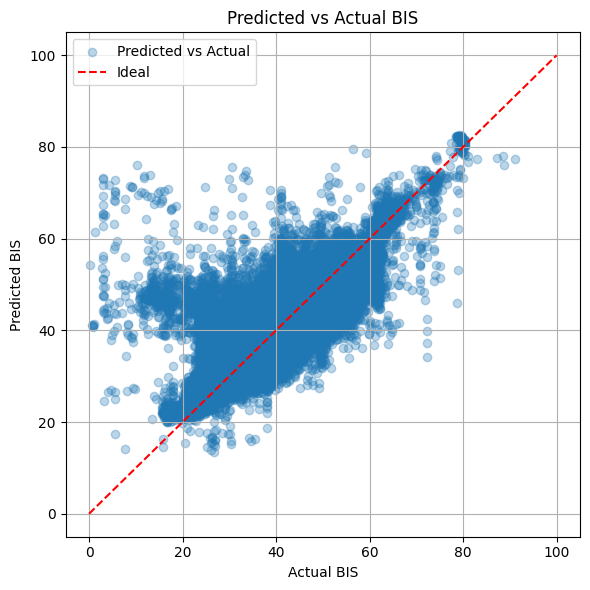

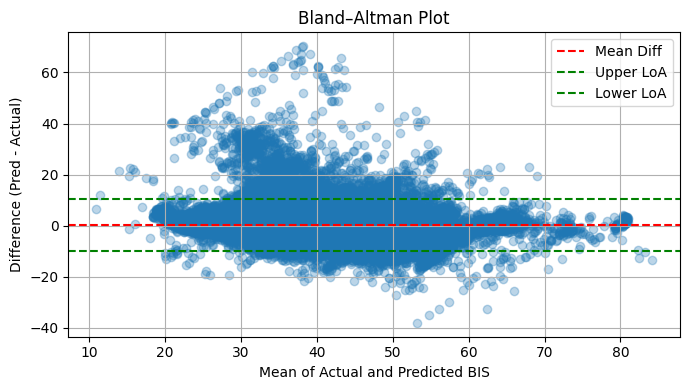

In [20]:
results = evaluate_model(model, train_loader, test_loader, device)


Evaluation Summary:
Train MAE: 3.243 | RMSE: 4.455 | R²: 0.730
Test  MAE: 3.320 | RMSE: 4.951 | R²: 0.686
Test  ±10 BIS Accuracy: 96.25%


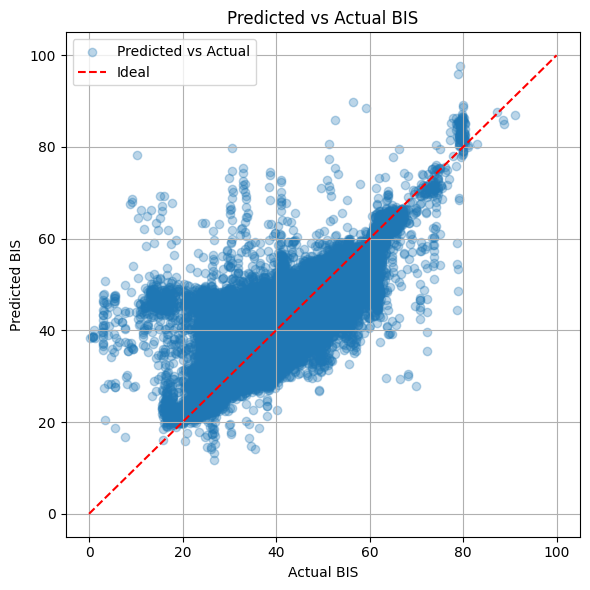

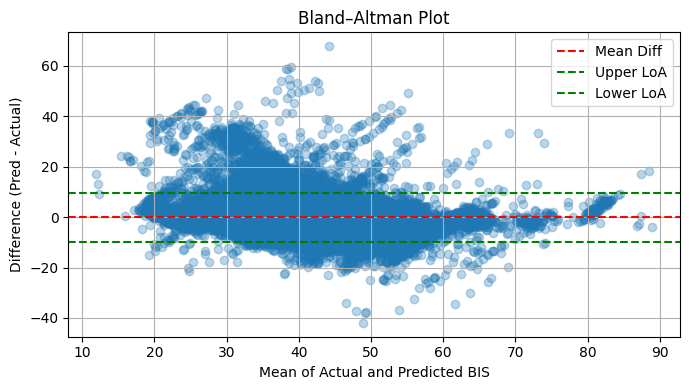

In [20]:
results = evaluate_model(model, train_loader, test_loader, device)


Evaluation Summary:
Train MAE: 3.027 | RMSE: 4.182 | R²: 0.761
Test  MAE: 3.363 | RMSE: 4.879 | R²: 0.708
Test  ±10 BIS Accuracy: 96.06%


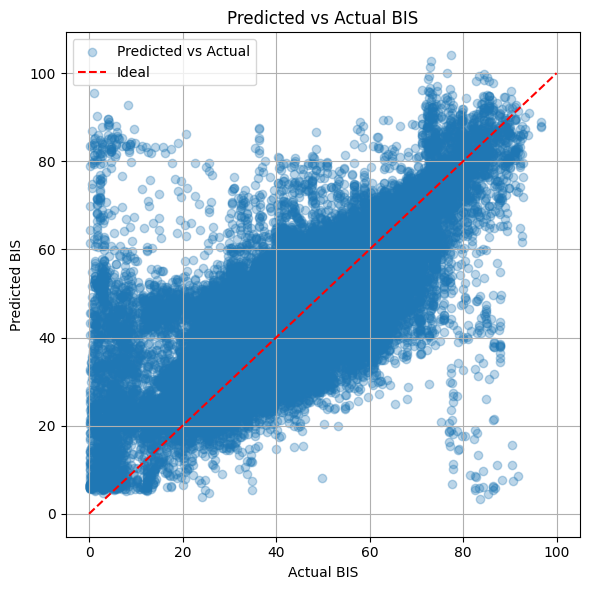

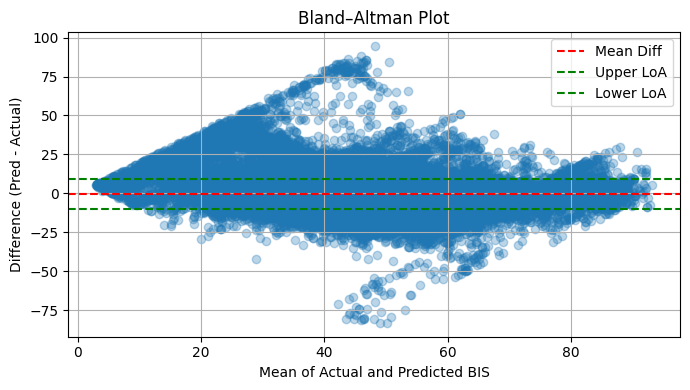

In [45]:
results = evaluate_model(model, train_loader, test_loader, device)


Evaluation Summary:
Train MAE: 2.855 | RMSE: 3.965 | R²: 0.786
Test  MAE: 3.375 | RMSE: 5.086 | R²: 0.669
Test  ±10 BIS Accuracy: 96.08%


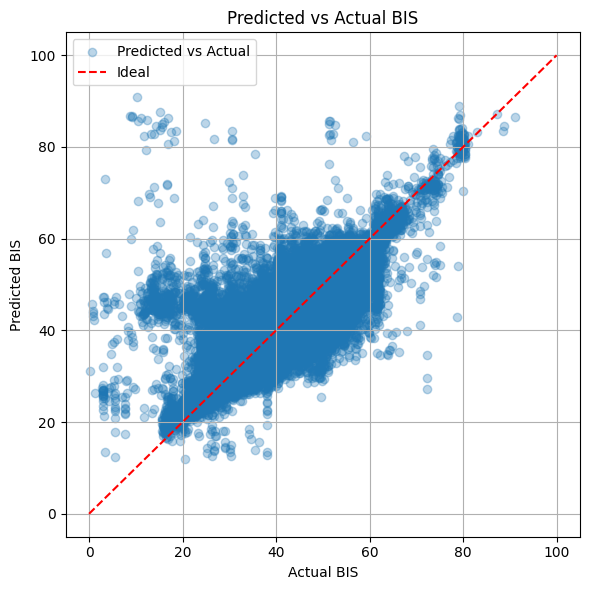

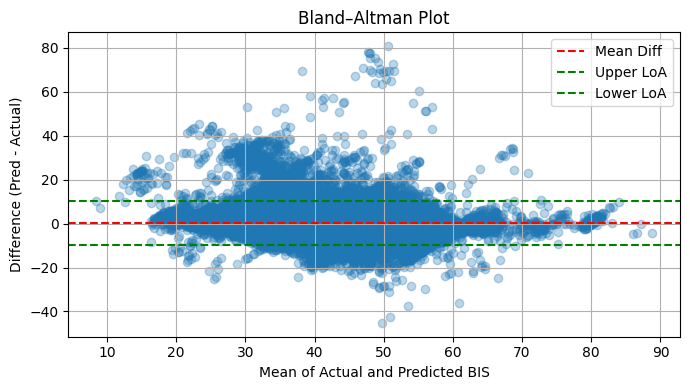

In [71]:
results = evaluate_model(model, train_loader, test_loader, device)


Evaluation Summary:
Train MAE: 3.299 | RMSE: 4.744 | R²: 0.693
Test  MAE: 3.502 | RMSE: 5.397 | R²: 0.627
Test  ±10 BIS Accuracy: 95.81%


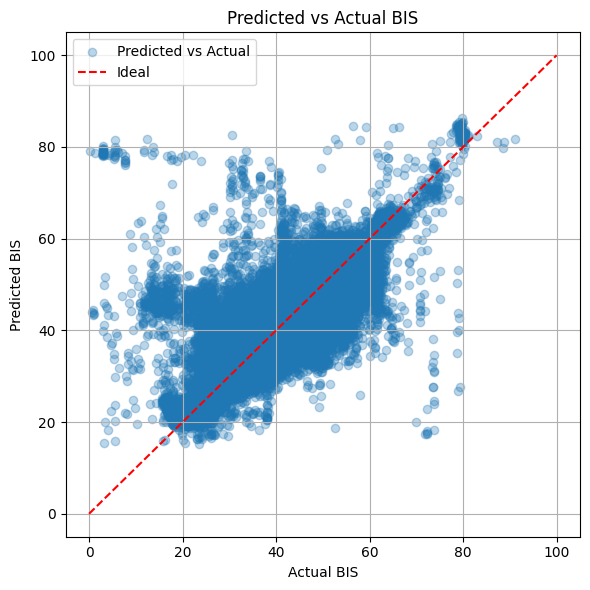

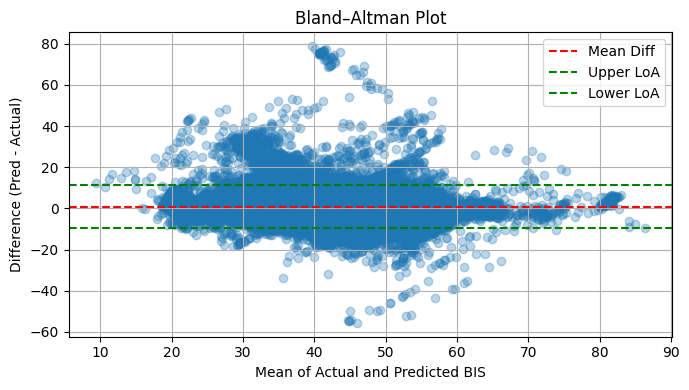

In [63]:
results = evaluate_model(model, train_loader, test_loader, device)


In [ ]:
results